Використай цей шаблон в роботі з датасетом.    
Ти можеш додавати комірки за потреби, але не змінюй структуру і послідовність питань.    
Обмежся функціями з наведених бібліотек.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

1. Переглянь список .json файлів, доступних за адресою https://github.com/prust/wikipedia-movie-data/tree/master.    
Відкрий будь-який файл, що містить у своїй назві рік і ознайомся з його структурою.    
Тепер сформуй список файлів, які ти будеш завантажувати.    
Для формування послідовності слід використати функцію numpy.arange.    
Довжина послідовності має становити не менше 5 датасетів(наприклад з 1960 по 2000  рік включно).    
Повну адресу сформуй через конкатенацію рядків.

In [2]:
# Створюємо послідовність: 1960, 1970, ..., 2000
decades = np.arange(1960, 2010, 10)
print(decades)

[1960 1970 1980 1990 2000]


In [3]:
# Cтворюємо повні URL-адреси
base_url = "https://raw.githubusercontent.com/prust/wikipedia-movie-data/master/movies-"
urls = [f"{base_url}{year}s.json" for year in decades]

for url in urls:
    print(url)

https://raw.githubusercontent.com/prust/wikipedia-movie-data/master/movies-1960s.json
https://raw.githubusercontent.com/prust/wikipedia-movie-data/master/movies-1970s.json
https://raw.githubusercontent.com/prust/wikipedia-movie-data/master/movies-1980s.json
https://raw.githubusercontent.com/prust/wikipedia-movie-data/master/movies-1990s.json
https://raw.githubusercontent.com/prust/wikipedia-movie-data/master/movies-2000s.json


2. Тепер послідовність дій наступна.   
Слід пройти по всім обраним тобою файлам, прочитати кожен, як json об'єкт.        
Позбутись зайвих стовпців: ['href', 'extract', 'thumbnail', 'thumbnail_width', 'thumbnail_height'].     
Залишити лише повні рядки(рядки без пропущених значень).     
Об'єднати інформацію з усіх файлів в єдиний датасет.

In [28]:
import requests

In [29]:
 # Список для збереження таблиць
dfs = [] 

In [30]:
# надсилаємо запит до URL
for url in urls:
    response = requests.get(url)  

In [31]:
# перетворюємо відповідь у JSON-об'єкт
data = response.json()

In [32]:
# створюємо таблицю з JSON-даних
df = pd.DataFrame(data)

In [33]:
 # додаємо таблицю до списку
dfs.append(df) 

In [34]:
final_df = pd.concat(dfs, ignore_index=True)

3. Перевір розмір фінального датасету. Він має включати 4(чотири) стовпчика. Кількість рядків залежить від обраної кількості файлів. Збережи собі копію у вигляді csv або json файлу. Це убезпечить тебе від форс-мажорів.

In [39]:
# 🔍 Перевіряємо розмір фінального датасету
# У ньому має бути 4 стовпці: title, year, cast, genres
print("Кількість рядків:", final_df.shape[0])   # кількість рядків у таблиці
print("Кількість стовпців:", final_df.shape[1]) # кількість стовпців у таблиці
print("Назви стовпців:", final_df.columns.tolist()) # список назв стовпців

Кількість рядків: 2430
Кількість стовпців: 9
Назви стовпців: ['title', 'year', 'cast', 'genres', 'href', 'extract', 'thumbnail', 'thumbnail_width', 'thumbnail_height']


In [40]:
# Очищаємо датасет від зайвих стовпців
# Залишаємо тільки потрібні 4 стовпці
final_df_cleaned = final_df[['title', 'year', 'cast', 'genres']]

In [41]:
# Перевіряємо розмір очищеного датасету
print("Кількість рядків після очищення:", final_df_cleaned.shape[0])
print("Кількість стовпців після очищення:", final_df_cleaned.shape[1])
print("Назви стовпців після очищення:", final_df_cleaned.columns.tolist())

Кількість рядків після очищення: 2430
Кількість стовпців після очищення: 4
Назви стовпців після очищення: ['title', 'year', 'cast', 'genres']


In [42]:
# Зберігаємо очищений датасет у форматі CSV
final_df_cleaned.to_csv("movies_cleaned.csv", index=False)

In [43]:
# Зберігаємо очищений датасет у форматі JSON
final_df_cleaned.to_json("movies_cleaned.json", orient="records", force_ascii=False)

In [44]:
# Повідомлення про успішне збереження
print("Очищений датасет успішно збережено у форматах CSV та JSON.")

Очищений датасет успішно збережено у форматах CSV та JSON.


4. Для json файлу не варто використовувати метод describe. Файл містить вкладені структури.    
Перевір вміст перших рядочків і використай метод info.

In [45]:
# Перевіряємо перші рядки очищеного датасету
print("Перші 5 рядків:")
print(final_df_cleaned.head())

Перші 5 рядків:
             title  year                                               cast  \
0   102 Dalmatians  2000       [Glenn Close, Gérard Depardieu, Alice Evans]   
1          28 Days  2000                  [Sandra Bullock, Viggo Mortensen]   
2        3 Strikes  2000                      [Brian Hooks, N'Bushe Wright]   
3      The 6th Day  2000  [Arnold Schwarzenegger, Robert Duvall, Michael...   
4  Across the Line  2000      [Brad Johnson, Adrienne Barbeau, Brian Bloom]   

                      genres  
0    [Comedy, Family, Crime]  
1            [Drama, Comedy]  
2                   [Comedy]  
3  [Science Fiction, Action]  
4        [Thriller, Western]  


In [46]:
# Перевіряємо загальну інформацію про датасет
print("\nІнформація про датасет:")
print(final_df_cleaned.info())


Інформація про датасет:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2430 entries, 0 to 2429
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   2430 non-null   object
 1   year    2430 non-null   int64 
 2   cast    2430 non-null   object
 3   genres  2430 non-null   object
dtypes: int64(1), object(3)
memory usage: 76.1+ KB
None


5. Тепер слід попрацювати з жанрами.    
Віднайди топ 10 жанрів за кількістю фільмів.    
Побудуй стовпчикову та кругову діаграму, а також виведи на екран підсумкову таблицю.

In [47]:
# Розгортаємо список жанрів у окремі рядки
genres_exploded = final_df_cleaned.explode('genres')

In [48]:
# Рахуємо кількість фільмів у кожному жанрі
genre_counts = genres_exploded['genres'].value_counts().head(10)

In [49]:
# Виводимо підсумкову таблицю
print("Топ 10 жанрів за кількістю фільмів:")
print(genre_counts)

Топ 10 жанрів за кількістю фільмів:
genres
Comedy             979
Drama              843
Action             310
Thriller           308
Romance            301
Horror             216
Crime              183
Science Fiction    150
Adventure          140
Animated           138
Name: count, dtype: int64


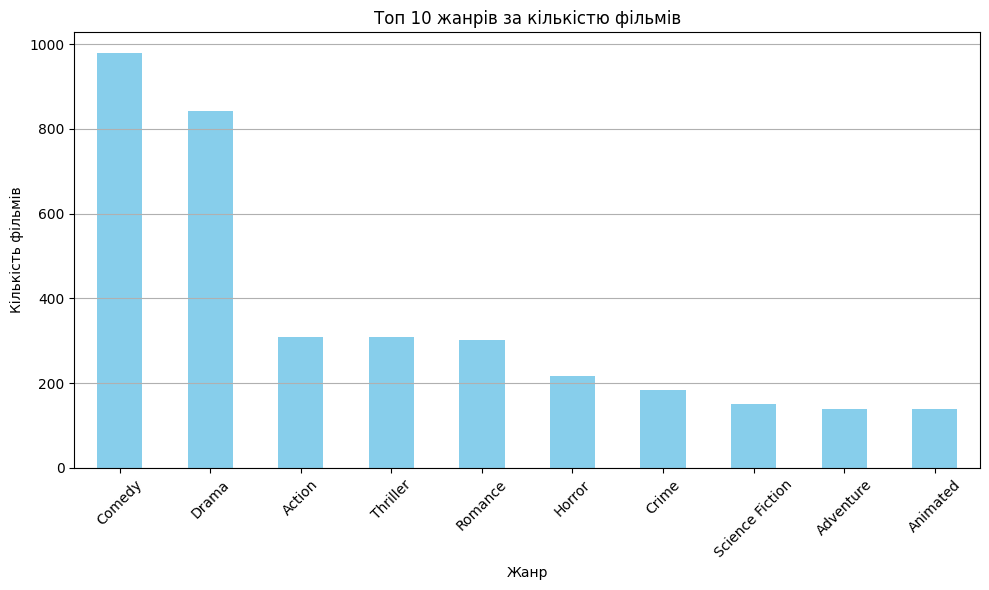

In [50]:
# Стовпчикова діаграма
plt.figure(figsize=(10, 6))
genre_counts.plot(kind='bar', color='skyblue')
plt.title("Топ 10 жанрів за кількістю фільмів")
plt.xlabel("Жанр")
plt.ylabel("Кількість фільмів")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

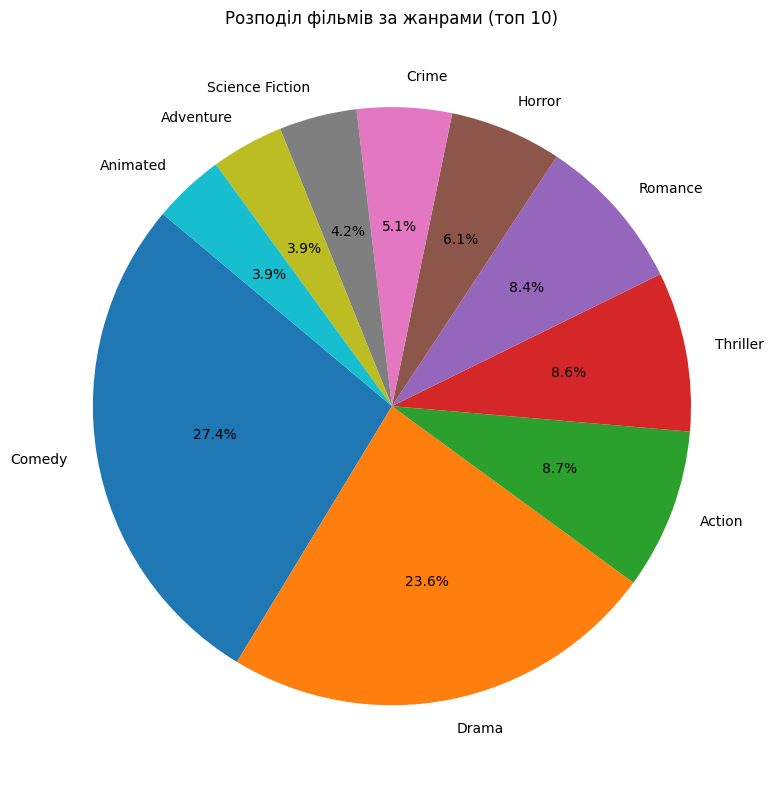

In [51]:
# Кругова діаграма
plt.figure(figsize=(8, 8))
genre_counts.plot(kind='pie', autopct='%1.1f%%', startangle=140)
plt.title("Розподіл фільмів за жанрами (топ 10)")
plt.ylabel("")  # прибираємо підпис осі Y
plt.tight_layout()
plt.show()

6. Тепер вибери 3 найпопулярніших жанри і подивись, як змінювалась їх популярність впродовж обраного тобою часового періода.     
Для цього підрахуй кількість фільмів в кожному жанрі за кожен рік спостереження.    
Виведи результат у вигляді лінійного графіка.

In [52]:
# Розгортаємо жанри у окремі рядки
genres_exploded = final_df_cleaned.explode('genres')

In [53]:
# Визначаємо топ‑3 найпопулярніших жанри
top3_genres = genres_exploded['genres'].value_counts().head(3).index.tolist()
print("Топ 3 жанри:", top3_genres)

Топ 3 жанри: ['Comedy', 'Drama', 'Action']


In [54]:
# Фільтруємо лише ці жанри
filtered = genres_exploded[genres_exploded['genres'].isin(top3_genres)]

In [55]:
# Групуємо: кількість фільмів по роках для кожного жанру
genre_year_counts = filtered.groupby(['year', 'genres']).size().unstack(fill_value=0)

<Figure size 1200x600 with 0 Axes>

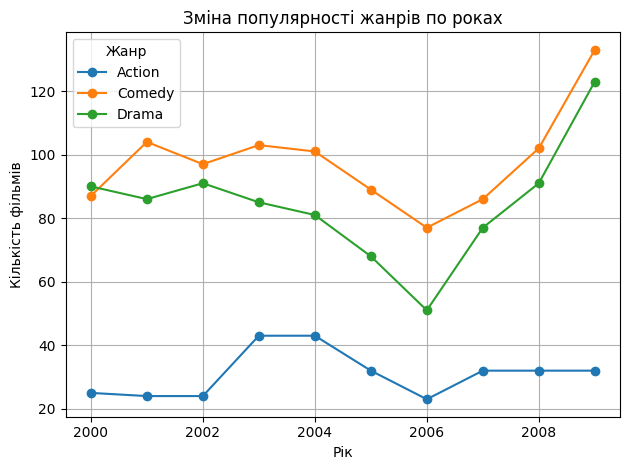

In [56]:
# Побудова лінійного графіка

plt.figure(figsize=(12, 6))
genre_year_counts.plot(kind='line', marker='o')
plt.title("Зміна популярності жанрів по роках")
plt.xlabel("Рік")
plt.ylabel("Кількість фільмів")
plt.grid(True)
plt.legend(title="Жанр")
plt.tight_layout()
plt.show()


7. Тепер слід попрацювати з акторами.     
Віднайди топ 10 акторів за кількістю фільмів.    
Побудуй стовпчикову або кругову діаграму, а також виведи на екран підсумукову таблицю.

In [57]:
# Розгортаємо список акторів у окремі рядки
actors_exploded = final_df_cleaned.explode('cast')

In [58]:
# Рахуємо кількість фільмів для кожного актора
actor_counts = actors_exploded['cast'].value_counts().head(10)

In [59]:
# Виводимо підсумкову таблицю
print("Топ 10 акторів за кількістю фільмів:")
print(actor_counts)

Топ 10 акторів за кількістю фільмів:
cast
Samuel L. Jackson    30
Owen Wilson          23
Morgan Freeman       23
Willem Dafoe         22
Matt Damon           22
Ben Stiller          21
Alec Baldwin         21
Bruce Willis         21
Justin Long          21
John Goodman         20
Name: count, dtype: int64


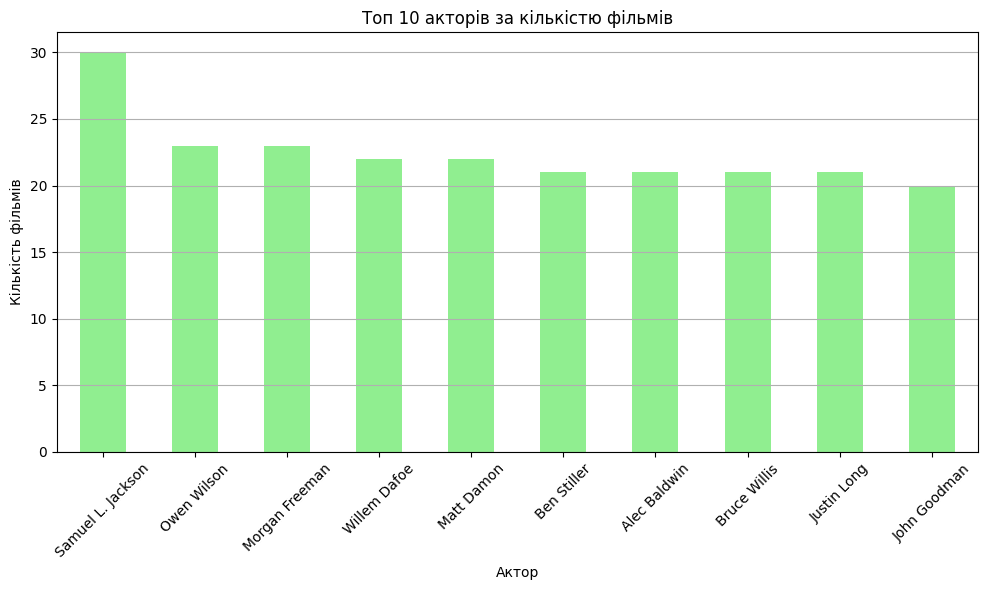

In [60]:
# Стовпчикова діаграма
plt.figure(figsize=(10, 6))
actor_counts.plot(kind='bar', color='lightgreen')
plt.title("Топ 10 акторів за кількістю фільмів")
plt.xlabel("Актор")
plt.ylabel("Кількість фільмів")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

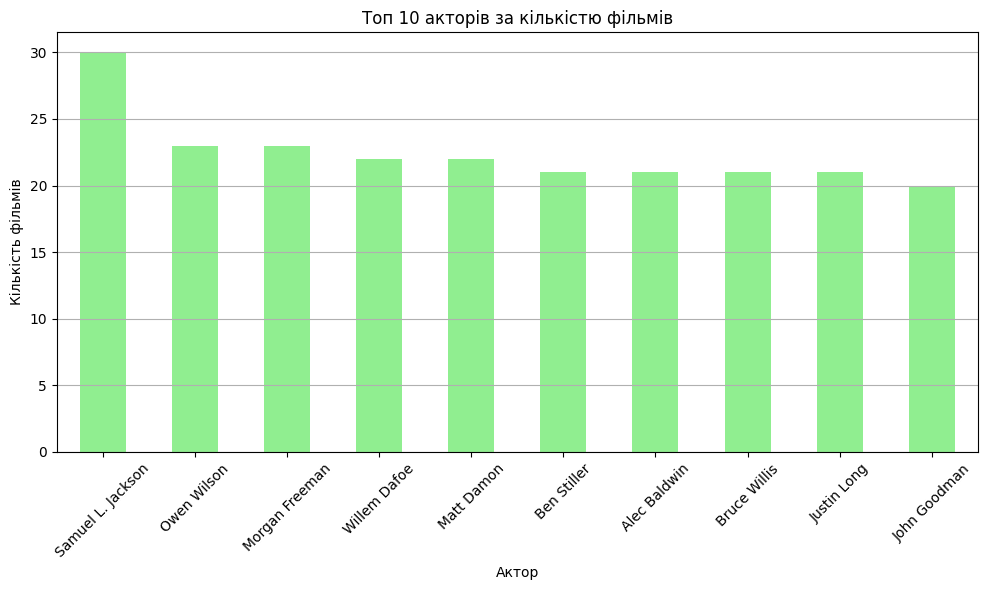

In [61]:
# Стовпчикова діаграма
plt.figure(figsize=(10, 6))
actor_counts.plot(kind='bar', color='lightgreen')
plt.title("Топ 10 акторів за кількістю фільмів")
plt.xlabel("Актор")
plt.ylabel("Кількість фільмів")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

8. Тепер вибери 3 найпопулярніших актори і подивись, як змінювалась їх популярність впродовж обраного тобою часового періода.
Для цього підрахуй кількість фільмів для кожного актора за кожен рік спостереження.    
Виведи результат у вигляді лінійного графіка.

In [62]:
# Розгортаємо список акторів у окремі рядки
actors_exploded = final_df_cleaned.explode('cast')

In [63]:
# Визначаємо топ‑3 найпопулярніших актори
top3_actors = actors_exploded['cast'].value_counts().head(3).index.tolist()
print("Топ 3 актори:", top3_actors)

Топ 3 актори: ['Samuel L. Jackson', 'Owen Wilson', 'Morgan Freeman']


In [64]:
# Фільтруємо лише ці актори
filtered_actors = actors_exploded[actors_exploded['cast'].isin(top3_actors)]

In [65]:
# Групуємо: кількість фільмів по роках для кожного актора
actor_year_counts = filtered_actors.groupby(['year', 'cast']).size().unstack(fill_value=0)

<Figure size 1200x600 with 0 Axes>

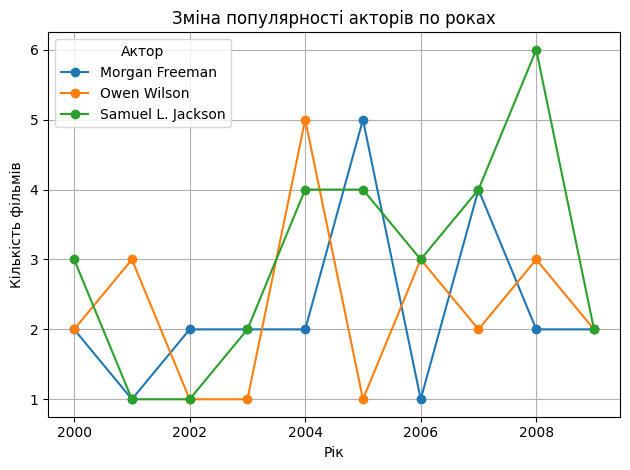

In [66]:
# Побудова лінійного графіка

plt.figure(figsize=(12, 6))
actor_year_counts.plot(kind='line', marker='o')
plt.title("Зміна популярності акторів по роках")
plt.xlabel("Рік")
plt.ylabel("Кількість фільмів")
plt.grid(True)
plt.legend(title="Актор")
plt.tight_layout()
plt.show()

***Бонусне завдання***       
Зосередься лише на 10 найпопулярніших акторах.     
 Порахуй, як часто кожен актор з'являється в фільмі, що належить до категорії топ-3 найпопулярніших жанри, та як часто в фільмі, що не включає топовий жанр.  
 Оціни пропорції для кожного актора у вигляді стовпчикової діаграми та у вигляді таблиці, де вказано також відсоток фільмів в топ жанрах.

In [67]:
# 🔄 Розгортаємо жанри та акторів
df_exploded = final_df_cleaned.explode('genres').explode('cast')

In [68]:
# Визначаємо топ‑10 акторів
top10_actors = df_exploded['cast'].value_counts().head(10).index.tolist()

In [69]:
# Визначаємо топ‑3 жанри
top3_genres = df_exploded['genres'].value_counts().head(3).index.tolist()

In [70]:
# Створюємо новий стовпець: чи фільм має топ‑жанр
df_exploded['has_top_genre'] = df_exploded['genres'].isin(top3_genres)

In [71]:
# Групуємо: кількість фільмів з/без топ‑жанру для кожного актора
actor_genre_stats = df_exploded[df_exploded['cast'].isin(top10_actors)] \
    .groupby(['cast', 'has_top_genre']) \
    .size() \
    .unstack(fill_value=0)

In [ ]:
# 🔁 Перейменовуємо колонки для зручності
actor_genre_stats = actor_genre_stats.rename(columns={
    True: 'З топ‑жанрами',
    False: 'Без топ‑жанрів'
})

In [72]:
# Додаємо відсоток фільмів з топ‑жанрами
actor_genre_stats['% з топ жанрами'] = round(
    actor_genre_stats['З топ‑жанрами'] / 
    (actor_genre_stats['З топ‑жанрами'] + actor_genre_stats['Без топ‑жанрів']) * 100, 1
)

In [73]:
# Виводимо таблицю
print("Таблиця: кількість фільмів з/без топ‑жанрів для кожного актора")
print(actor_genre_stats)

Таблиця: кількість фільмів з/без топ‑жанрів для кожного актора
has_top_genre      False  True  % в топ жанрах
cast                                          
Alec Baldwin          29    21            42.0
Bruce Willis          28    21            42.9
Dennis Quaid          28    18            39.1
Frank Welker          42    11            20.8
Jeff Bennett          40    12            23.1
John Goodman          26    25            49.0
Morgan Freeman        31    16            34.0
Patrick Warburton     31    16            34.0
Samuel L. Jackson     42    20            32.3
Stanley Tucci         22    28            56.0


In [75]:
# Побудова стовпчикової діаграми
plt.figure(figsize=(12, 6))
actor_genre_stats[['З топ‑жанрами', 'Без топ‑жанрів']].plot(
    kind='bar', stacked=True, color=['skyblue', 'lightgray']
)
plt.title("Кількість фільмів з/без топ‑жанрів для топ‑10 акторів")
plt.xlabel("Актор")
plt.ylabel("Кількість фільмів")
plt.legend(["З топ‑жанрами", "Без топ‑жанрів"])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

IndexError: Boolean index has wrong length: 2 instead of 3

<Figure size 1200x600 with 0 Axes>